# 03. Gayrimenkul Birim Fiyat Tahmini

**Kategori:** Regresyon  
**Gerçek veri seti:** UCI Real Estate Valuation  
**Veri kaynağı:** [https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set](https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set)  
**Amaç:** Konum, bina yaşı ve çevresel özelliklerden birim alan fiyatını tahmin etmek.

Bu notebook; veri yükleme, veri kalitesi kontrolü, keşifsel veri analizi (EDA), görselleştirme,
modelleme, değerlendirme ve çıktı yorumlama adımlarını ayrı ayrı gösterir. Sentetik veya rastgele
üretilmiş gözlem kullanılmamıştır. Rastgelelik yalnızca tekrarlanabilir eğitim/test ayrımı ve
algoritma başlangıcı için `random_state=42` ile kontrol edilmiştir.

In [1]:
from pathlib import Path
import json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
RESULT_DIR = ROOT / "results"
MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
print("Proje kökü:", ROOT.resolve())

Proje kökü: /workspace/scratch/f0b9bcae3580/Rabia_Yel_21_Gercek_Veri_Projesi


## 1. Veri kontrolü ve EDA

In [2]:
df = pd.read_csv(DATA_DIR / "real_estate_valuation.csv").drop(columns="no")
display(df.head())
display(pd.DataFrame({"tip": df.dtypes, "eksik": df.isna().sum()}))
print("Boyut:", df.shape, "| Tekrar:", df.duplicated().sum())
display(df.describe().T)

Boyut: (414, 7) | Tekrar: 0


,transaction_date,house_age,distance_to_mrt,convenience_stores,latitude,longitude,price_per_unit_area
0,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


,tip,eksik
transaction_date,float64,0
house_age,float64,0
distance_to_mrt,float64,0
convenience_stores,int64,0
latitude,float64,0
longitude,float64,0
price_per_unit_area,float64,0


,count,mean,std,min,25%,50%,75%,max
transaction_date,414.0,2013.148953,0.281995,2012.666667,2012.916667,2013.166667,2013.416667,2013.583333
house_age,414.0,17.712560,11.392485,0.000000,9.025000,16.100000,28.150000,43.800000
distance_to_mrt,414.0,1083.885689,1262.109595,23.382840,289.324800,492.231300,1454.279000,6488.021000
convenience_stores,414.0,4.094203,2.945562,0.000000,1.000000,4.000000,6.000000,10.000000
latitude,414.0,24.969030,0.012410,24.932070,24.963000,24.971100,24.977455,25.014590
longitude,414.0,121.533361,0.015347,121.473530,121.528085,121.538630,121.543305,121.566270
price_per_unit_area,414.0,37.980193,13.606488,7.600000,27.700000,38.450000,46.600000,117.500000


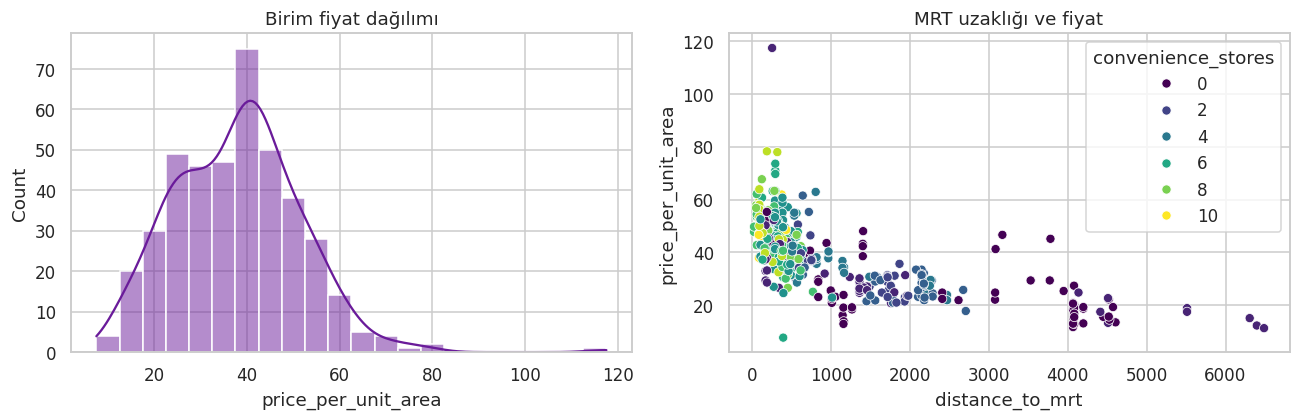

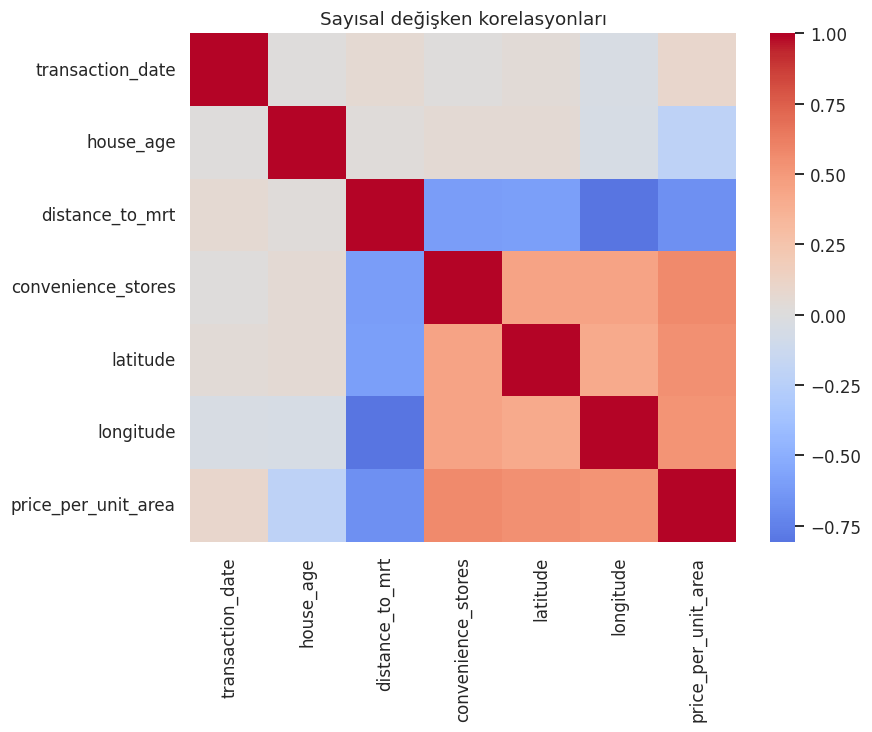

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df.price_per_unit_area, kde=True, ax=axes[0], color="#6A1B9A")
axes[0].set(title="Birim fiyat dağılımı")
sns.scatterplot(data=df, x="distance_to_mrt", y="price_per_unit_area",
                hue="convenience_stores", palette="viridis", ax=axes[1])
axes[1].set(title="MRT uzaklığı ve fiyat")
plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Sayısal değişken korelasyonları"); plt.show()

## 2. Model karşılaştırması

In [4]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X = df.drop(columns="price_per_unit_area")
y = df.price_per_unit_area
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.20,
                                                    random_state=RANDOM_STATE)
candidates = {
    "Doğrusal Regresyon": make_pipeline(StandardScaler(), LinearRegression()),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=250, min_samples_leaf=2,
                                            random_state=RANDOM_STATE, n_jobs=-1),
}
fitted = {name: model.fit(X_train, y_train) for name, model in candidates.items()}
preds = {name: model.predict(X_test) for name, model in fitted.items()}
scores = pd.DataFrame({name: {"MAE": mean_absolute_error(y_test, pred),
                              "RMSE": root_mean_squared_error(y_test, pred),
                              "R2": r2_score(y_test, pred)}
                       for name, pred in preds.items()}).T.sort_values("MAE")
display(scores.round(3))

,MAE,RMSE,R2
Random Forest,3.732,5.503,0.820
Gradient Boosting,3.902,5.844,0.796
Doğrusal Regresyon,5.305,7.315,0.681


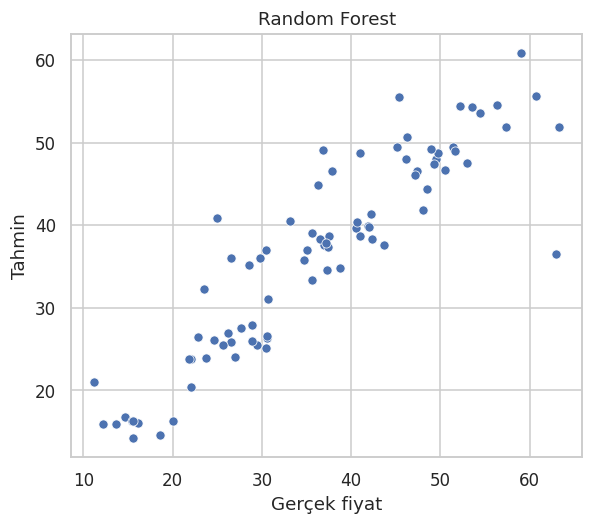

In [5]:
best_name = scores.index[0]; best_model = fitted[best_name]
best_pred = preds[best_name]
plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test, y=best_pred)
plt.xlabel("Gerçek fiyat"); plt.ylabel("Tahmin"); plt.title(best_name)
plt.show()
joblib.dump({"best_name": best_name, "best_model": best_model,
             "all_models": fitted, "features": X.columns.tolist(),
             "metrics": scores.to_dict()}, MODEL_DIR / "03_gayrimenkul.joblib")
json.dump({"best_model": best_name, **scores.loc[best_name].to_dict()},
          open(RESULT_DIR / "03_gayrimenkul.json", "w"), indent=2)

## Sonuç

Konuma bağlı fiyat ilişkisi doğrusal olmayabildiği için ağaç tabanlı modeller doğrusal modele karşı
sınandı. Sonuçlar Taiwan/New Taipei City verisinin koşullarını yansıtır; Türkiye pazarı için aynı
model doğrudan kullanılmamalı, yerel tapu ve ilan verisiyle yeniden eğitilmelidir.

## Kaynak çözümle karşılaştırma

Ödevde verilen proje listelerindeki örnek yaklaşımın odağı **gayrimenkul fiyat tahmini için tek model** biçimindedir.
Bu notebookta **gerçek işlem verisi, konumsal EDA, üç model ve pazar aktarılabilirliği uyarısı** eklenmiştir. Böylece yalnızca modeli çalıştırmak yerine veri kalitesi,
EDA, görsel kanıt, uygun metrik ve yeniden kullanılabilir model kaydı birlikte sunulmuştur.

Kaynak listeler: [75 Data Science Projects](https://python.plainenglish.io/85-data-science-projects-c03c8750599e)
ve [230 Machine Learning Projects](https://medium.com/coders-camp/230-machine-learning-projects-with-python-5d0c7abf8265).